# Bank Customer Churn Prediction
### End-to-End ML Pipeline & Model Comparison

Predict whether a bank customer will leave (`Exited = 1`) or stay (`Exited = 0`) — a binary classification problem.

## 1. Problem Definition

Predicting churn lets a bank act early (offers, support) to retain at-risk customers.

**Goal:** load & clean the data → EDA → engineer features → train & compare multiple classifiers → pick the best model.

## 2. Dataset Description

Customer attributes: credit score, country, gender, age, tenure, balance, number of products, credit card ownership, activity status, estimated salary.
**Target:** `Exited` (1 = left, 0 = stayed).

In [2]:
import pandas as pd
import numpy as np

## 3. Loading the Dataset

Loaded from `Churn_Modelling.csv` with Pandas.

In [3]:
df = pd.read_csv("Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 4. Initial Data Exploration

Check shape, columns, dtypes, and summary statistics before cleaning.

In [4]:
df.shape

(10000, 14)

In [5]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [7]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [8]:
df.describe(include='object')

,Surname,Geography,Gender
count,10000,10000,10000
unique,2932,3,2
top,Smith,France,Male
freq,32,5014,5457


## 5. Data Cleaning

Steps: check missing values → check duplicates → drop irrelevant columns → check target balance → final sanity check.

### 5.1 Missing Values

In [9]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [10]:
df.isnull().sum().sum()

np.int64(0)

**Result:** no missing values — no imputation needed.

### 5.2 Duplicate Rows

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df = df.drop_duplicates()
df.shape

(10000, 14)

### 5.3 Removing Irrelevant Columns

Dropped `RowNumber`, `CustomerId`, `Surname` — identifiers with no predictive value.

In [13]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### 5.4 Data Types After Cleaning

In [14]:
df.dtypes

CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

### 5.5 Unique Values in Categorical Columns

In [15]:
print("Unique values in Geography:")
print(df['Geography'].unique())

print("\nUnique values in Gender:")
print(df['Gender'].unique())

Unique values in Geography:
['France' 'Spain' 'Germany']

Unique values in Gender:
['Female' 'Male']


In [16]:
df.nunique()

CreditScore         460
Geography             3
Gender                2
Age                  70
Tenure               11
Balance            6382
NumOfProducts         4
HasCrCard             2
IsActiveMember        2
EstimatedSalary    9999
Exited                2
dtype: int64

### 5.6 Target Variable Check

In [17]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [18]:
df['Exited'].value_counts(normalize=True) * 100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

**Result:** target is imbalanced — stayed customers outnumber churned ones. Accuracy alone won't be enough; we'll also track Precision, Recall, F1, and the confusion matrix.

### 5.7 Final Check

Confirms: irrelevant columns removed, no missing values, no duplicates — ready for EDA.

In [19]:
print("Dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicated rows:", df.duplicated().sum())
print("\nData types:")
print(df.dtypes)

Dataset shape: (10000, 11)

Missing values:
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Duplicated rows: 0

Data types:
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


## Data Cleaning Summary

Loaded data → explored structure → checked missing values & duplicates → dropped `RowNumber`, `CustomerId`, `Surname` → checked categoricals & target distribution. Ready for EDA.

## 6. Exploratory Data Analysis (EDA)

Covers: target distribution, categorical vs. churn, numerical distributions, numerical vs. churn, correlations, and outliers.

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

### 6.1 Target Variable Distribution

In [21]:
target_counts = df['Exited'].value_counts()
target_counts

Exited
0    7963
1    2037
Name: count, dtype: int64

In [22]:
target_percentages = df['Exited'].value_counts(normalize=True) * 100
target_percentages

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

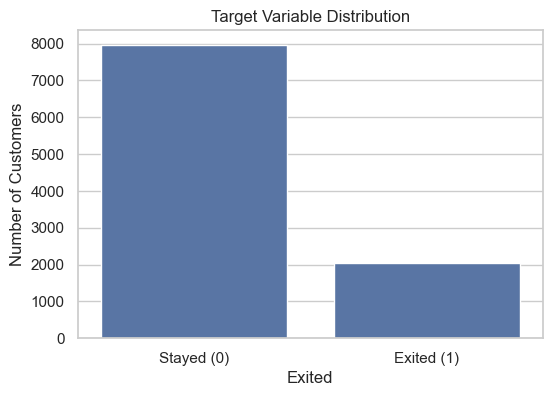

In [23]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Exited', data=df)
plt.title('Target Variable Distribution')
plt.xlabel('Exited')
plt.ylabel('Number of Customers')
plt.xticks([0, 1], ['Stayed (0)', 'Exited (1)'])
plt.show()

**Observation:** imbalanced target — ~79.6% stayed, ~20.4% left. We'll rely on Precision/Recall/F1 (not just accuracy), with extra focus on Recall for class `1`.

### 6.2 Categorical Features vs. Churn

`Geography` and `Gender` compared against churn rate.

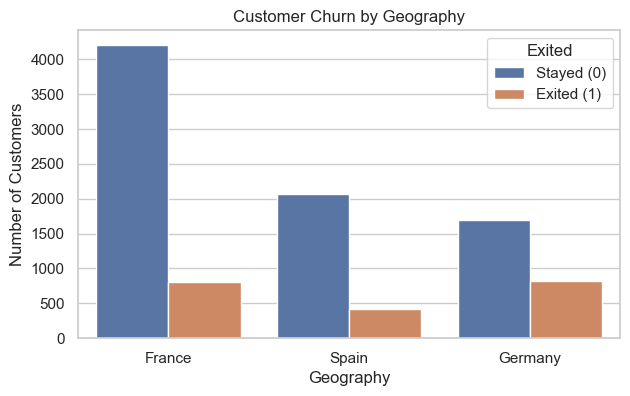

In [24]:
plt.figure(figsize=(7, 4))
sns.countplot(x='Geography', hue='Exited', data=df)
plt.title('Customer Churn by Geography')
plt.xlabel('Geography')
plt.ylabel('Number of Customers')
plt.legend(title='Exited', labels=['Stayed (0)', 'Exited (1)'])
plt.show()

In [25]:
geography_churn_rate = df.groupby('Geography')['Exited'].mean() * 100
geography_churn_rate.sort_values(ascending=False)

Geography
Germany    32.443204
Spain      16.673395
France     16.154767
Name: Exited, dtype: float64

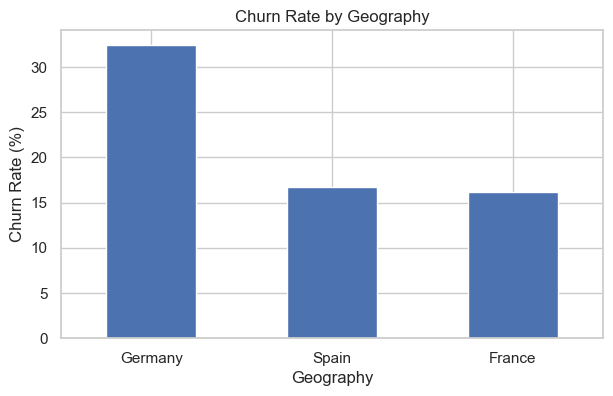

In [26]:
plt.figure(figsize=(7, 4))
geography_churn_rate.sort_values(ascending=False).plot(kind='bar')
plt.title('Churn Rate by Geography')
plt.xlabel('Geography')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

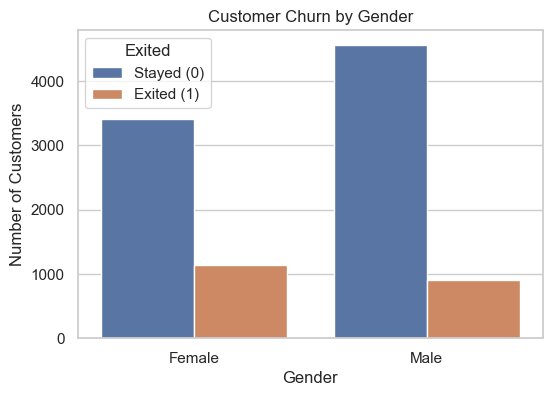

In [27]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Gender', hue='Exited', data=df)
plt.title('Customer Churn by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.legend(title='Exited', labels=['Stayed (0)', 'Exited (1)'])
plt.show()

In [28]:
gender_churn_rate = df.groupby('Gender')['Exited'].mean() * 100
gender_churn_rate.sort_values(ascending=False)

Gender
Female    25.071539
Male      16.455928
Name: Exited, dtype: float64

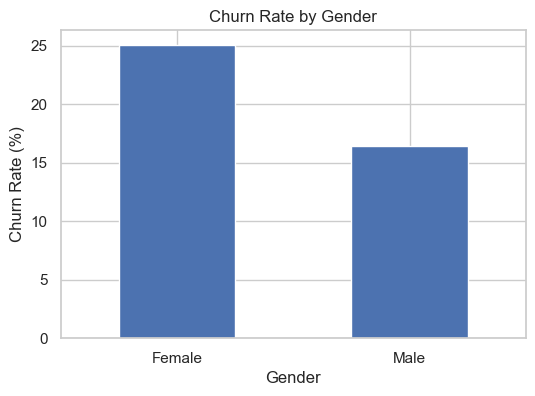

In [29]:
plt.figure(figsize=(6, 4))
gender_churn_rate.sort_values(ascending=False).plot(kind='bar')
plt.title('Churn Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

**Observation:** churn differs by group — Germany ~32.4% vs. ~16% for France/Spain; females ~25.1% vs. males ~16.5%. Both features are worth encoding.

### 6.3 Numerical Feature Distributions

In [30]:
numerical_cols = [
    'CreditScore',
    'Age',
    'Tenure',
    'Balance',
    'NumOfProducts',
    'EstimatedSalary'
]

numerical_cols

['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

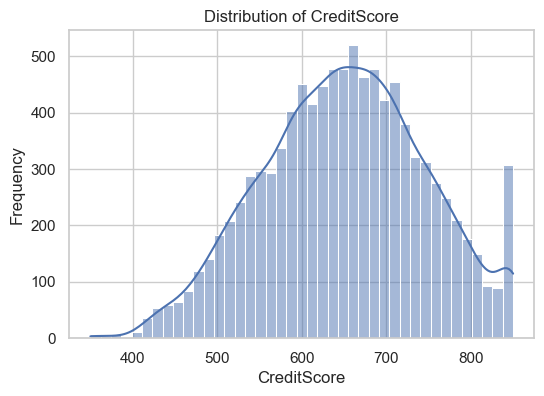

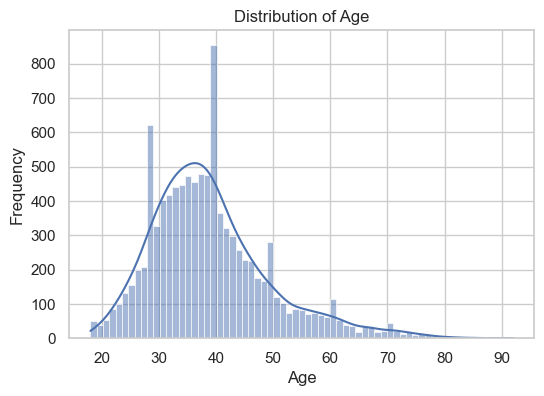

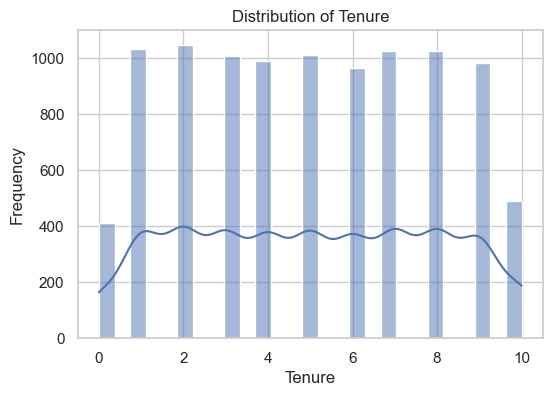

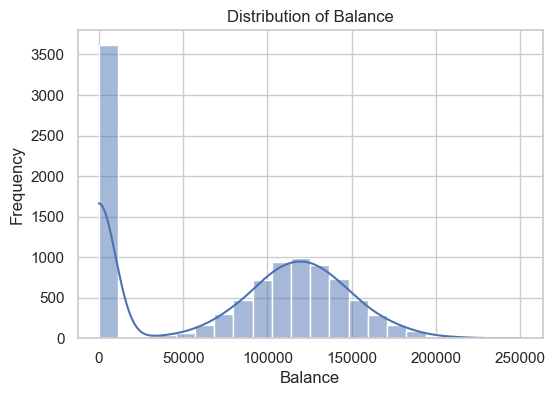

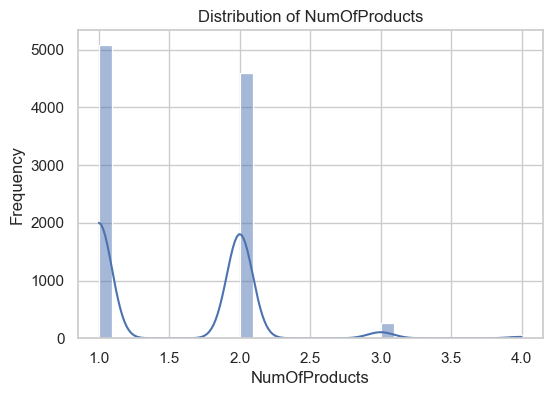

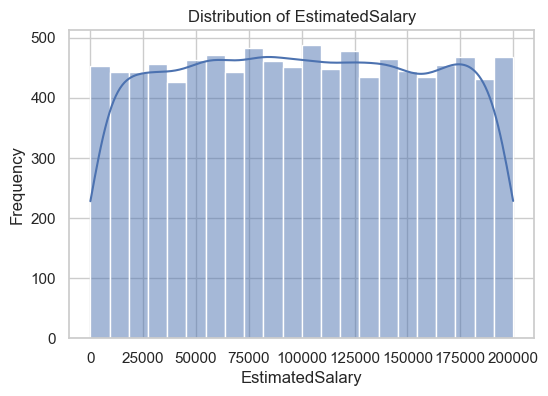

In [31]:
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

**Observation:** features have very different scales (e.g. `Balance`/`EstimatedSalary` vs. `Age`/`Tenure`) — scaling will be needed for KNN/SVM.

### 6.4 Numerical Features vs. Churn

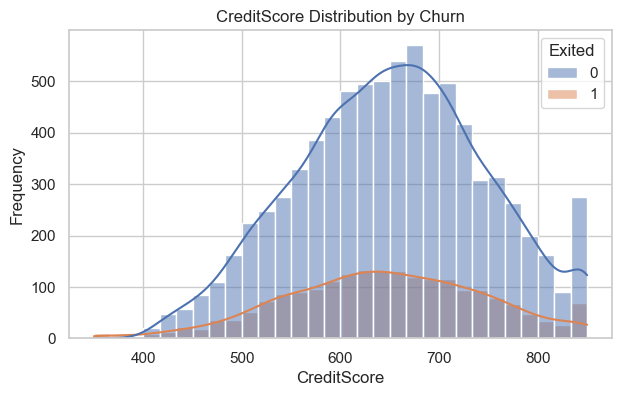

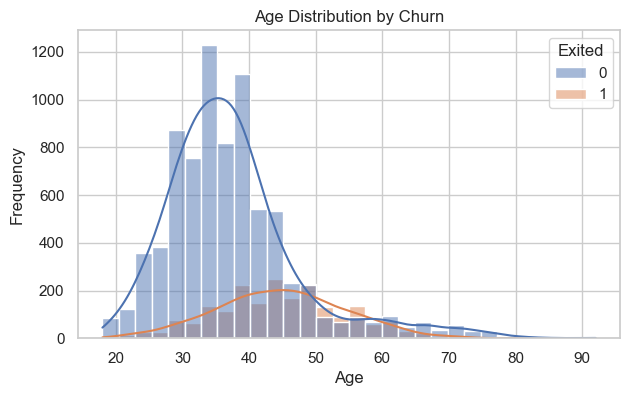

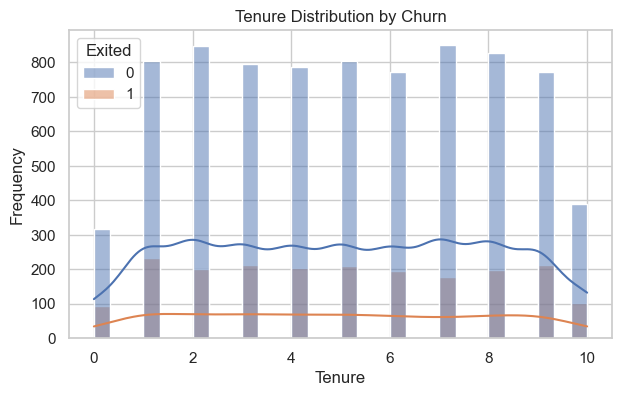

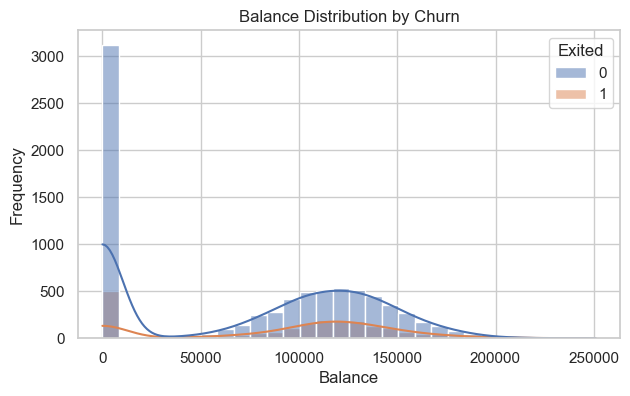

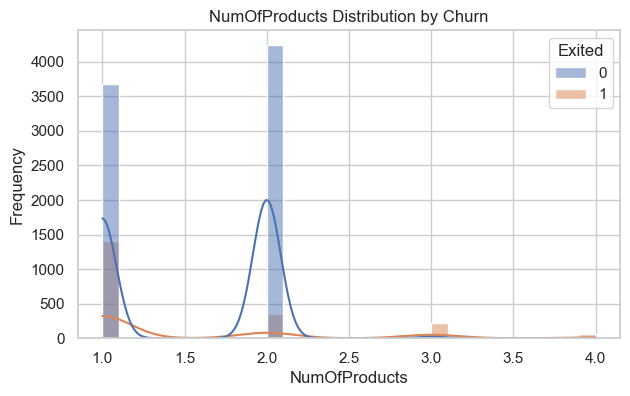

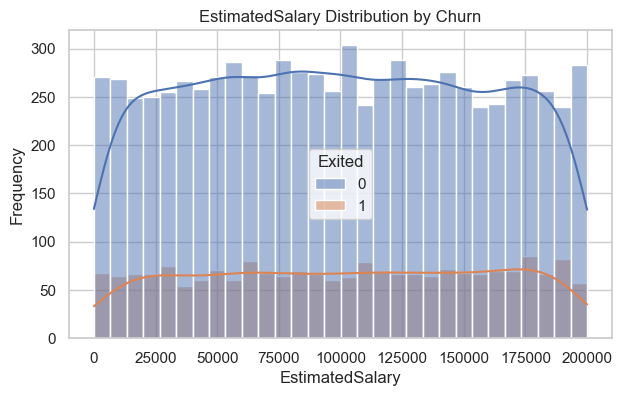

In [32]:
for col in numerical_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=df, x=col, hue='Exited', kde=True, bins=30)
    plt.title(f'{col} Distribution by Churn')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

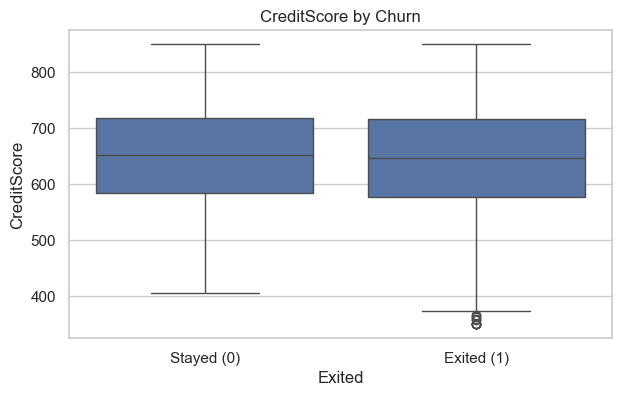

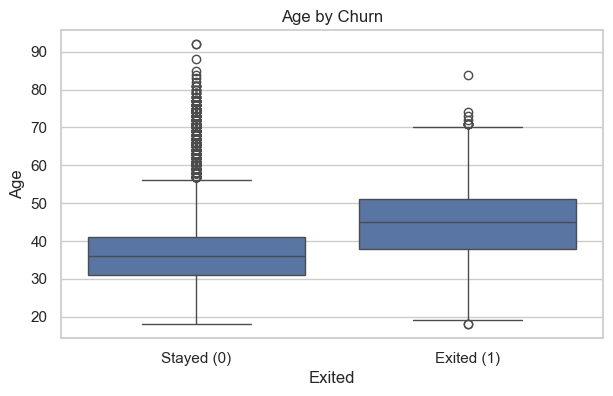

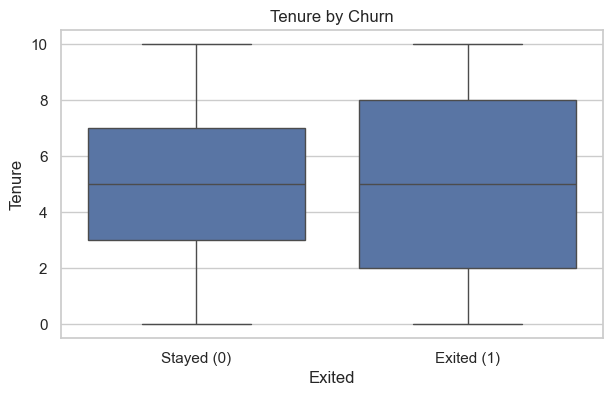

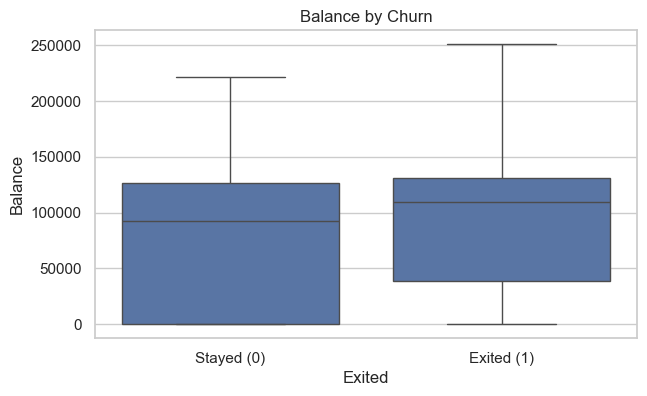

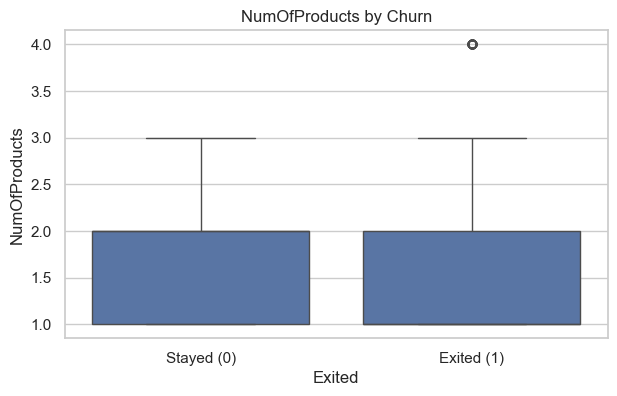

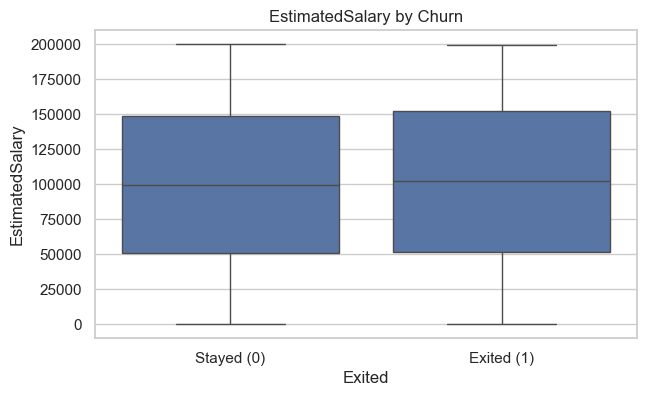

In [33]:
for col in numerical_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x='Exited', y=col, data=df)
    plt.title(f'{col} by Churn')
    plt.xlabel('Exited')
    plt.ylabel(col)
    plt.xticks([0, 1], ['Stayed (0)', 'Exited (1)'])
    plt.show()

**Observation:** `Age` shows a clear shift between churned and retained customers; `Balance`, `CreditScore`, `EstimatedSalary` show weaker but potentially useful patterns.

### 6.5 Binary Features vs. Churn

`HasCrCard` and `IsActiveMember`.

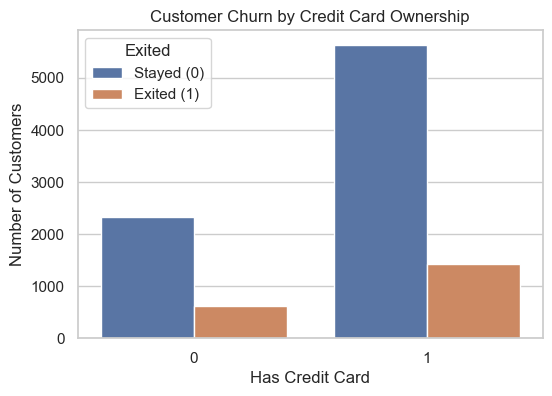

In [34]:
plt.figure(figsize=(6, 4))
sns.countplot(x='HasCrCard', hue='Exited', data=df)
plt.title('Customer Churn by Credit Card Ownership')
plt.xlabel('Has Credit Card')
plt.ylabel('Number of Customers')
plt.legend(title='Exited', labels=['Stayed (0)', 'Exited (1)'])
plt.show()

In [35]:
has_cr_card_churn_rate = df.groupby('HasCrCard')['Exited'].mean() * 100
has_cr_card_churn_rate

HasCrCard
0    20.814941
1    20.184266
Name: Exited, dtype: float64

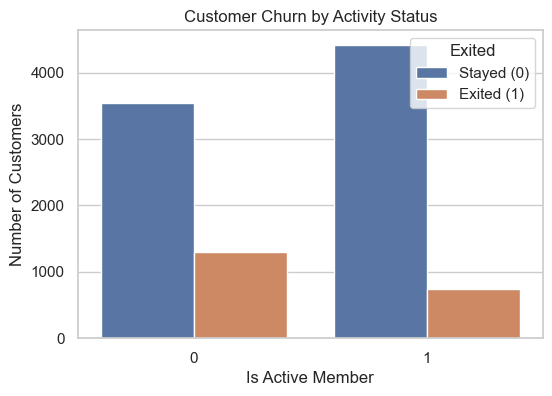

In [36]:
plt.figure(figsize=(6, 4))
sns.countplot(x='IsActiveMember', hue='Exited', data=df)
plt.title('Customer Churn by Activity Status')
plt.xlabel('Is Active Member')
plt.ylabel('Number of Customers')
plt.legend(title='Exited', labels=['Stayed (0)', 'Exited (1)'])
plt.show()

In [37]:
active_member_churn_rate = df.groupby('IsActiveMember')['Exited'].mean() * 100
active_member_churn_rate

IsActiveMember
0    26.850897
1    14.269074
Name: Exited, dtype: float64

**Observation:** `HasCrCard` barely affects churn. `IsActiveMember` matters a lot — inactive customers churn at ~26.9% vs. ~14.3% for active ones.

### 6.6 Correlation Matrix

In [38]:
correlation_matrix = df.corr(numeric_only=True)
correlation_matrix

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
CreditScore,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094
Age,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323
Tenure,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001
Balance,0.006268,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533
NumOfProducts,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820
HasCrCard,-0.005458,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138
IsActiveMember,0.025651,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128
EstimatedSalary,-0.001384,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097
Exited,-0.027094,0.285323,-0.014001,0.118533,-0.047820,-0.007138,-0.156128,0.012097,1.000000


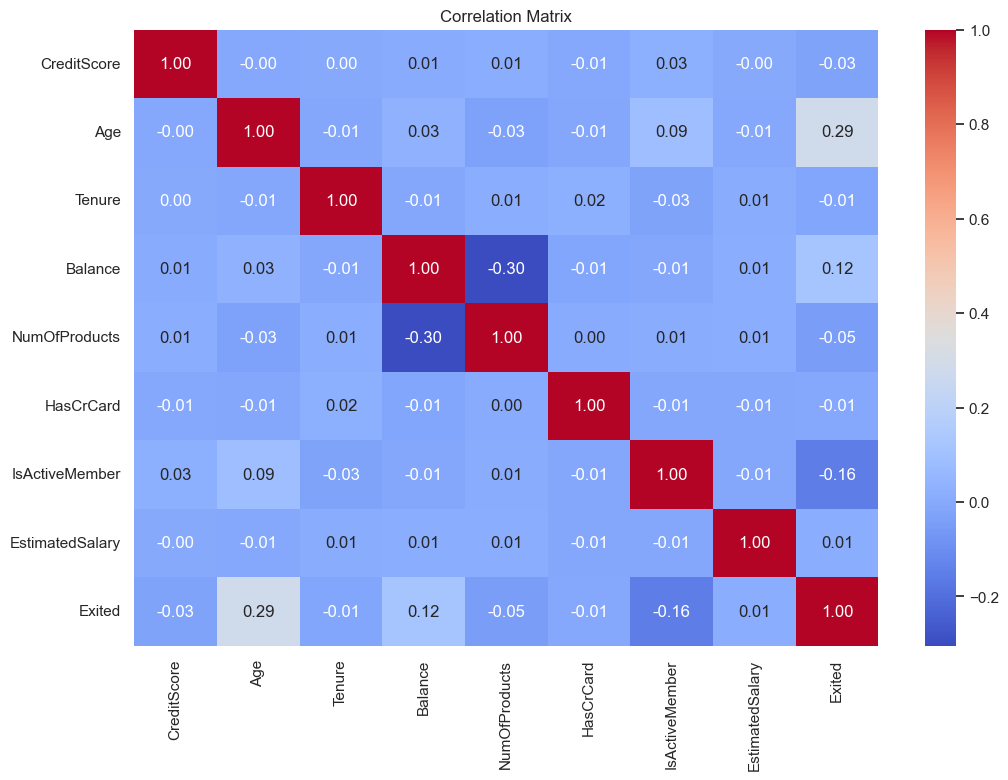

In [39]:
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title('Correlation Matrix')
plt.show()

In [40]:
target_correlation = correlation_matrix['Exited'].sort_values(ascending=False)
target_correlation

Exited             1.000000
Age                0.285323
Balance            0.118533
EstimatedSalary    0.012097
HasCrCard         -0.007138
Tenure            -0.014001
CreditScore       -0.027094
NumOfProducts     -0.047820
IsActiveMember    -0.156128
Name: Exited, dtype: float64

**Observation:** no strong multicollinearity between features. `Age` correlates positively with churn, `IsActiveMember` negatively — but correlation only captures linear relationships, so low-correlation features may still matter for tree-based models.

### 6.7 Scatter Plot Analysis

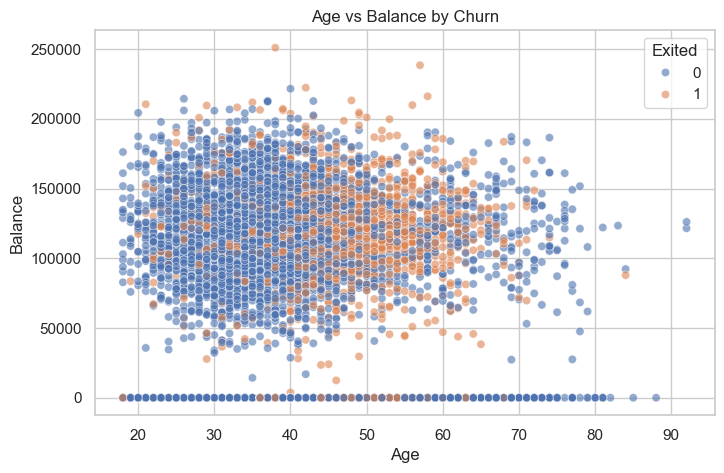

In [41]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Age', y='Balance', hue='Exited', alpha=0.6)
plt.title('Age vs Balance by Churn')
plt.xlabel('Age')
plt.ylabel('Balance')
plt.show()

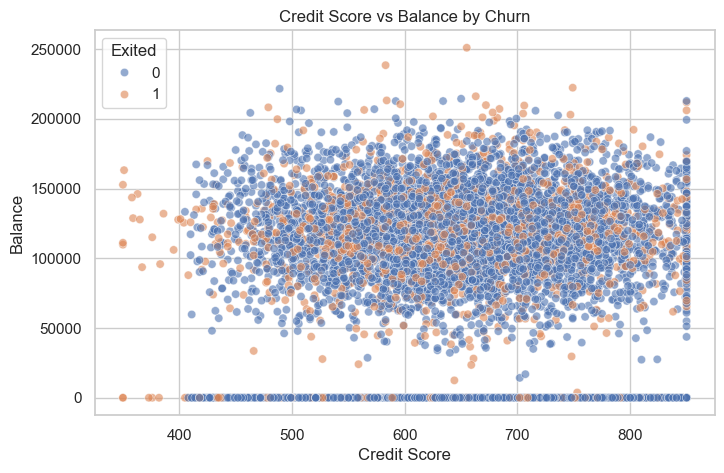

In [42]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='CreditScore', y='Balance', hue='Exited', alpha=0.6)
plt.title('Credit Score vs Balance by Churn')
plt.xlabel('Credit Score')
plt.ylabel('Balance')
plt.show()

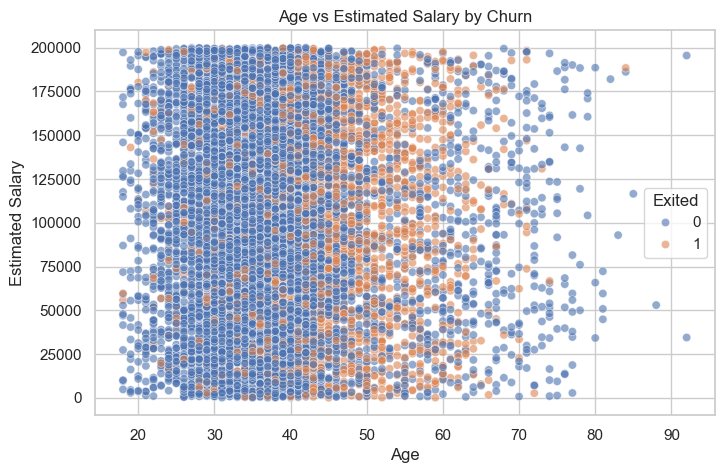

In [43]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Age', y='EstimatedSalary', hue='Exited', alpha=0.6)
plt.title('Age vs Estimated Salary by Churn')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.show()

**Observation:** classes aren't linearly separable on any single feature pair — churn depends on feature combinations, which favors non-linear models like Random Forest/SVM/XGBoost.

### 6.8 Outlier Detection

Checked via boxplots / IQR on numerical features.

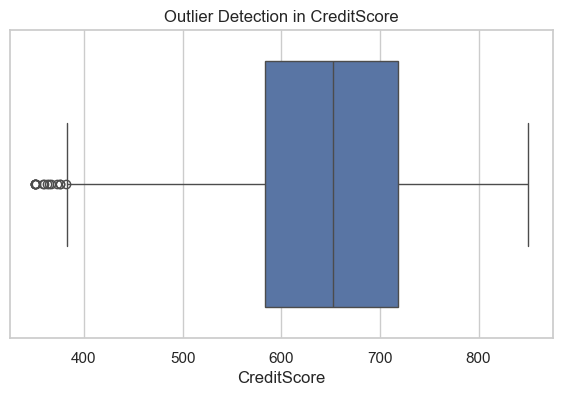

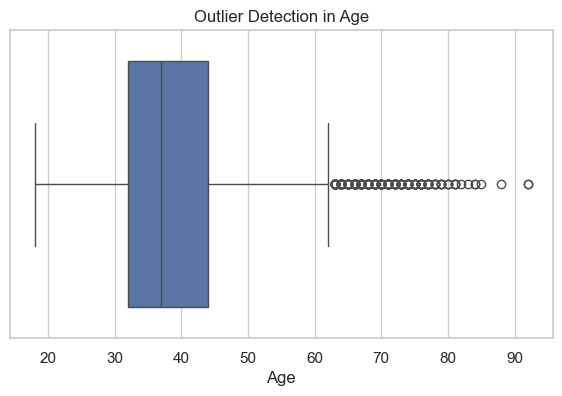

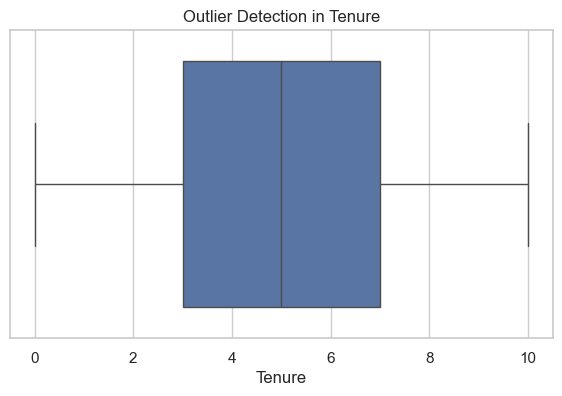

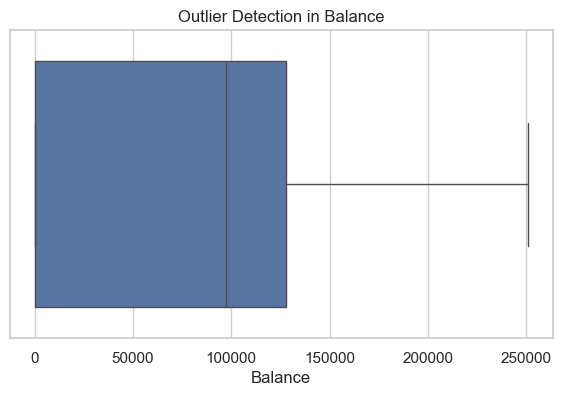

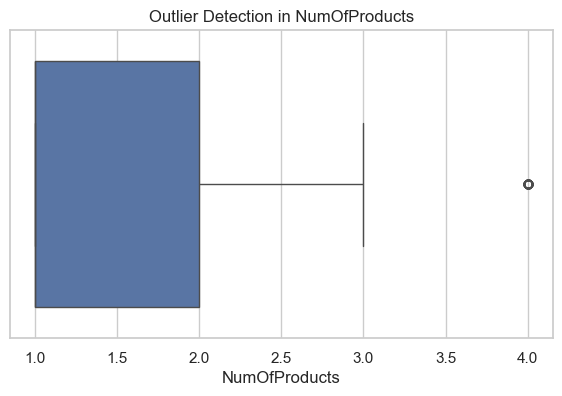

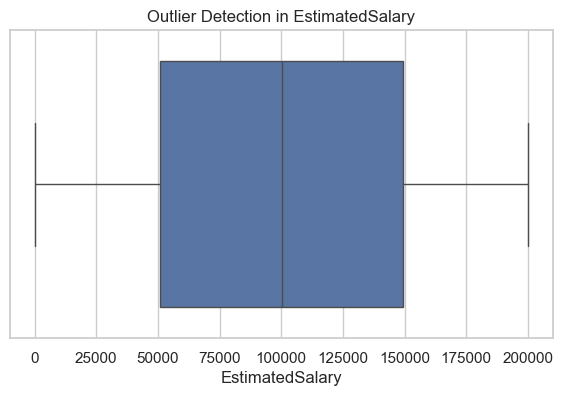

In [44]:
for col in numerical_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Outlier Detection in {col}')
    plt.xlabel(col)
    plt.show()

In [45]:
def count_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    
    return len(outliers), lower_bound, upper_bound

In [46]:
outlier_summary = []

for col in numerical_cols:
    outlier_count, lower_bound, upper_bound = count_outliers_iqr(df, col)
    outlier_summary.append({
        'Feature': col,
        'Outlier Count': outlier_count,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
outlier_summary_df

,Feature,Outlier Count,Lower Bound,Upper Bound
0,CreditScore,15,383.00000,919.00000
1,Age,359,14.00000,62.00000
2,Tenure,0,-3.00000,13.00000
3,Balance,0,-191466.36000,319110.60000
4,NumOfProducts,60,-0.50000,3.50000
5,EstimatedSalary,0,-96577.09625,296967.45375


**Decision:** outliers found mainly in `Age`, `CreditScore`, `NumOfProducts`, but they look like valid customer behavior rather than errors — kept as-is; scaling handles the rest.

## EDA Summary

- Target imbalanced (~80/20)
- `Geography` (Germany highest) and `Gender` (female higher) both relate to churn
- Numerical features need scaling
- `IsActiveMember` is a strong signal; `HasCrCard` is not
- No multicollinearity issues
- Classes aren't linearly separable → favor non-linear models
- Outliers kept (mainly `Age`, `CreditScore`, `NumOfProducts`)

Ready for feature engineering.

## 7. Feature Engineering and Preprocessing

Two parts: **(1)** engineer new features, **(2)** split data, encode, and scale.

### 7.1 Feature Engineering

New features based on EDA insights: `AgeGroup`, `IsZeroBalance`, `BalanceSalaryRatio`.

In [47]:
df_fe = df.copy()
df_fe.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### 7.1.1 AgeGroup

`Young` (<30), `Adult` (30–44), `Middle_Aged` (45–59), `Senior` (60+).

In [48]:
def create_age_group(age):
    if age < 30:
        return 'Young'
    elif age < 45:
        return 'Adult'
    elif age < 60:
        return 'Middle_Aged'
    else:
        return 'Senior'
df_fe['AgeGroup'] = df_fe['Age'].apply(create_age_group)
df_fe[['Age', 'AgeGroup']].head(10)

,Age,AgeGroup
0,42,Adult
1,41,Adult
2,42,Adult
3,39,Adult
4,43,Adult
5,44,Adult
6,50,Middle_Aged
7,29,Young
8,44,Adult
9,27,Young


In [49]:
df_fe['AgeGroup'].value_counts()

AgeGroup
Adult          6019
Middle_Aged    1814
Young          1641
Senior          526
Name: count, dtype: int64

In [50]:
age_group_churn_rate = df_fe.groupby('AgeGroup')['Exited'].mean() * 100
age_group_churn_rate.sort_values(ascending=False)

AgeGroup
Middle_Aged    49.448732
Senior         27.946768
Adult          14.437614
Young           7.556368
Name: Exited, dtype: float64

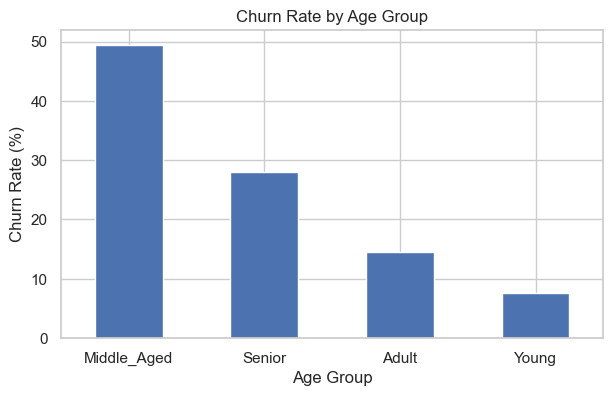

In [51]:
plt.figure(figsize=(7, 4))
age_group_churn_rate.sort_values(ascending=False).plot(kind='bar')
plt.title('Churn Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

**Observation:** `Middle_Aged` and `Senior` churn most; younger customers churn least — a useful signal.

### 7.1.2 IsZeroBalance

Binary flag for zero vs. non-zero account balance.

In [52]:
df_fe['IsZeroBalance'] = (df_fe['Balance'] == 0).astype(int)
df_fe[['Balance', 'IsZeroBalance']].head(10)

,Balance,IsZeroBalance
0,0.00,1
1,83807.86,0
2,159660.80,0
3,0.00,1
4,125510.82,0
5,113755.78,0
6,0.00,1
7,115046.74,0
8,142051.07,0
9,134603.88,0


In [53]:
df_fe['IsZeroBalance'].value_counts()

IsZeroBalance
0    6383
1    3617
Name: count, dtype: int64

In [54]:
zero_balance_churn_rate = df_fe.groupby('IsZeroBalance')['Exited'].mean() * 100
zero_balance_churn_rate

IsZeroBalance
0    24.079586
1    13.823611
Name: Exited, dtype: float64

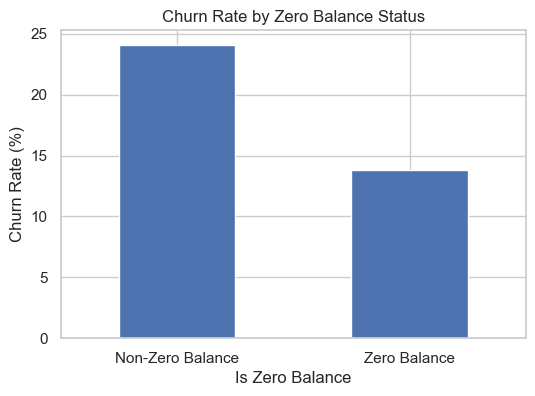

In [55]:
plt.figure(figsize=(6, 4))
zero_balance_churn_rate.plot(kind='bar')
plt.title('Churn Rate by Zero Balance Status')
plt.xlabel('Is Zero Balance')
plt.ylabel('Churn Rate (%)')
plt.xticks([0, 1], ['Non-Zero Balance', 'Zero Balance'], rotation=0)
plt.show()

**Observation:** non-zero-balance customers actually churn *more* — a counterintuitive but useful pattern for the model.

### 7.1.3 BalanceSalaryRatio

`log(1 + Balance / EstimatedSalary)` — compares balance to salary; the log keeps extreme ratios (from very small salaries) in check.

In [56]:
df_fe['BalanceSalaryRatio'] = np.log1p(df_fe['Balance'] / (df_fe['EstimatedSalary'] + 1))
df_fe[['Balance', 'EstimatedSalary', 'BalanceSalaryRatio']].head(10)

,Balance,EstimatedSalary,BalanceSalaryRatio
0,0.00,101348.88,0.000000
1,83807.86,112542.58,0.556566
2,159660.80,113931.57,0.876036
3,0.00,93826.63,0.000000
4,125510.82,79084.10,0.950512
5,113755.78,149756.71,0.565086
6,0.00,10062.80,0.000000
7,115046.74,119346.88,0.674964
8,142051.07,74940.50,1.063155
9,134603.88,71725.73,1.056616


In [57]:
df_fe['BalanceSalaryRatio'].describe()

count    10000.000000
mean         0.657663
std          0.773475
min          0.000000
25%          0.000000
50%          0.557899
75%          0.921876
max          9.187264
Name: BalanceSalaryRatio, dtype: float64

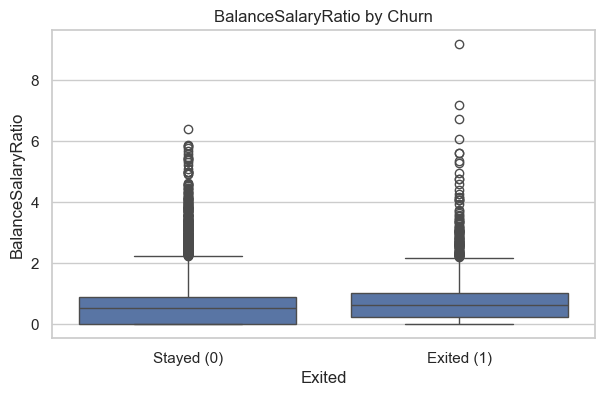

In [58]:
plt.figure(figsize=(7, 4))
sns.boxplot(x='Exited', y='BalanceSalaryRatio', data=df_fe)
plt.title('BalanceSalaryRatio by Churn')
plt.xlabel('Exited')
plt.ylabel('BalanceSalaryRatio')
plt.xticks([0, 1], ['Stayed (0)', 'Exited (1)'])
plt.show()

**Observation:** the log transform keeps this ratio stable and model-friendly.

### 7.1.4 Feature Engineering Summary

Added `AgeGroup`, `IsZeroBalance`, `BalanceSalaryRatio` — all grounded in EDA findings.

In [59]:
df_fe.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,IsZeroBalance,BalanceSalaryRatio
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,Adult,1,0.000000
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,Adult,0,0.556566
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,Adult,0,0.876036
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,Adult,1,0.000000
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,Adult,0,0.950512


In [60]:
df_fe.shape

(10000, 14)

## 7.2 Preparing Data for ML

Target: `Exited`. Features: everything else.

In [61]:
X = df_fe.drop('Exited', axis=1)
y = df_fe['Exited']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 13)
y shape: (10000,)


### 7.3 Numerical vs. Categorical Features

Needed to know what to scale vs. encode.

In [62]:
numerical_features = [
    'CreditScore',
    'Age',
    'Tenure',
    'Balance',
    'NumOfProducts',
    'HasCrCard',
    'IsActiveMember',
    'EstimatedSalary',
    'IsZeroBalance',
    'BalanceSalaryRatio'
]

categorical_features = [
    'Geography',
    'Gender',
    'AgeGroup'
]

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'IsZeroBalance', 'BalanceSalaryRatio']

Categorical Features:
['Geography', 'Gender', 'AgeGroup']


### 7.4 Train-Test Split

Stratified split (`stratify=y`) to preserve the class ratio in both sets.

In [63]:
from sklearn.model_selection import train_test_split

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8000, 13)
X_test shape: (2000, 13)
y_train shape: (8000,)
y_test shape: (2000,)


In [65]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training target distribution:
Exited
0    79.625
1    20.375
Name: proportion, dtype: float64

Testing target distribution:
Exited
0    79.65
1    20.35
Name: proportion, dtype: float64


**Observation:** stratification keeps the imbalance consistent across train/test.

### 7.5 Preprocessing Pipeline

`StandardScaler` for numerical features + `OneHotEncoder` for categorical features, combined via `ColumnTransformer`.

In [66]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [67]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['CreditScore', 'Age', 'Tenure', 'Balance',
                                  'NumOfProducts', 'HasCrCard',
                                  'IsActiveMember', 'EstimatedSalary',
                                  'IsZeroBalance', 'BalanceSalaryRatio']),
                                ('cat',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['Geography', 'Gender', 'AgeGroup'])])

**Why StandardScaler?** Features like `Age` and `Balance` sit on very different scales, which hurts distance/margin-based models (Logistic Regression, KNN, SVM).

**Why OneHotEncoder?** `Geography`, `Gender`, `AgeGroup` are text categories that models can't use directly.

In [68]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)

X_train_processed shape: (8000, 16)
X_test_processed shape: (2000, 16)


**Note on data leakage:** the preprocessor is `fit` on training data only and `transform`-ed on test data — the model never sees test-set statistics during fitting.

## Preprocessing Summary

Engineered 3 new features → split into X/y → identified numerical vs. categorical columns → stratified train/test split → built a `StandardScaler` + `OneHotEncoder` pipeline, fit on training data only. Ready to train.

## 8. Model Training and Evaluation

**Baseline:** Logistic Regression, Naive Bayes.
**Advanced:** KNN, SVM, Random Forest, XGBoost.

Evaluated on Accuracy, Precision, Recall, F1, and confusion matrix — with extra weight on Recall/F1 for class `1` given the imbalance.

### 8.1 Imports

In [69]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

### 8.2 XGBoost

Added as an extra model — strong default choice for tabular data.

In [70]:
from xgboost import XGBClassifier

### 8.3 Handling Class Imbalance

`class_weight='balanced'` for applicable models, `scale_pos_weight` for XGBoost; evaluation leans on Recall/F1 rather than accuracy.

In [71]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Negative class count:", negative_count)
print("Positive class count:", positive_count)
print("scale_pos_weight:", scale_pos_weight)

Negative class count: 6370
Positive class count: 1630
scale_pos_weight: 3.9079754601226995


### 8.4 Evaluation Helper Function

A reusable function to compute the standard metrics for each model.

In [72]:
def evaluate_model(model_name, y_true, y_pred):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0)
    }

## 9. Baseline Models

Logistic Regression and Naive Bayes — a simple reference point before trying more complex models.

### 9.1 Logistic Regression

Predicts churn probability despite the "regression" name — used here for binary classification.

In [73]:
log_reg_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
log_reg_model.fit(X_train_processed, y_train)
y_pred_log_reg = log_reg_model.predict(X_test_processed)
log_reg_result = evaluate_model('Logistic Regression', y_test, y_pred_log_reg)
log_reg_result

{'Model': 'Logistic Regression',
 'Accuracy': 0.727,
 'Precision': 0.39824304538799415,
 'Recall': 0.6683046683046683,
 'F1-Score': 0.4990825688073395}

In [74]:
print(classification_report(y_test, y_pred_log_reg, target_names=['Stayed (0)', 'Exited (1)']))

              precision    recall  f1-score   support

  Stayed (0)       0.90      0.74      0.81      1593
  Exited (1)       0.40      0.67      0.50       407

    accuracy                           0.73      2000
   macro avg       0.65      0.71      0.66      2000
weighted avg       0.80      0.73      0.75      2000



### 9.2 Naive Bayes

Probabilistic model that assumes feature independence — a simple but useful baseline.

In [75]:
nb_model = GaussianNB()
nb_model.fit(X_train_processed, y_train)
y_pred_nb = nb_model.predict(X_test_processed)
nb_result = evaluate_model('Naive Bayes', y_test, y_pred_nb)
nb_result

{'Model': 'Naive Bayes',
 'Accuracy': 0.7815,
 'Precision': 0.47093023255813954,
 'Recall': 0.597051597051597,
 'F1-Score': 0.5265438786565547}

In [76]:
print(classification_report(y_test, y_pred_nb, target_names=['Stayed (0)', 'Exited (1)']))

              precision    recall  f1-score   support

  Stayed (0)       0.89      0.83      0.86      1593
  Exited (1)       0.47      0.60      0.53       407

    accuracy                           0.78      2000
   macro avg       0.68      0.71      0.69      2000
weighted avg       0.80      0.78      0.79      2000



### 9.3 Baseline Results

In [77]:
baseline_results = pd.DataFrame([
    log_reg_result,
    nb_result
])
baseline_results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.7270,0.398243,0.668305,0.499083
1,Naive Bayes,0.7815,0.470930,0.597052,0.526544


**Analysis:** Logistic Regression F1 ≈ `0.499`, Naive Bayes F1 ≈ `0.527` — Naive Bayes slightly ahead. Both baselines are limited by class imbalance, with False Negatives (missed churners) the main risk to watch.

## 10. Advanced Models

KNN, SVM, Random Forest, XGBoost — built to capture non-linear patterns the baselines miss.

### 10.1 KNN

Distance-based; sensitive to feature scale, hence the `StandardScaler` step.

In [78]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_processed, y_train)
y_pred_knn = knn_model.predict(X_test_processed)
knn_result = evaluate_model('KNN', y_test, y_pred_knn)
knn_result

{'Model': 'KNN',
 'Accuracy': 0.844,
 'Precision': 0.6848249027237354,
 'Recall': 0.43243243243243246,
 'F1-Score': 0.5301204819277109}

In [79]:
print(classification_report(y_test, y_pred_knn, target_names=['Stayed (0)', 'Exited (1)']))

              precision    recall  f1-score   support

  Stayed (0)       0.87      0.95      0.91      1593
  Exited (1)       0.68      0.43      0.53       407

    accuracy                           0.84      2000
   macro avg       0.78      0.69      0.72      2000
weighted avg       0.83      0.84      0.83      2000



### 10.2 SVM

Finds the best separating boundary; uses `class_weight='balanced'` for the imbalance.

In [80]:
svm_model = SVC(
    kernel='rbf',
    class_weight='balanced',
    probability=True,
    random_state=42
)
svm_model.fit(X_train_processed, y_train)
y_pred_svm = svm_model.predict(X_test_processed)
svm_result = evaluate_model('SVM', y_test, y_pred_svm)
svm_result

{'Model': 'SVM',
 'Accuracy': 0.7915,
 'Precision': 0.4917763157894737,
 'Recall': 0.7346437346437347,
 'F1-Score': 0.5891625615763547}

In [81]:
print(classification_report(y_test, y_pred_svm, target_names=['Stayed (0)', 'Exited (1)']))

              precision    recall  f1-score   support

  Stayed (0)       0.92      0.81      0.86      1593
  Exited (1)       0.49      0.73      0.59       407

    accuracy                           0.79      2000
   macro avg       0.71      0.77      0.72      2000
weighted avg       0.83      0.79      0.81      2000



### 10.3 Random Forest

Ensemble of decision trees; uses `class_weight='balanced'`.

In [82]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train_processed, y_train)
y_pred_rf = rf_model.predict(X_test_processed)
rf_result = evaluate_model('Random Forest', y_test, y_pred_rf)
rf_result

{'Model': 'Random Forest',
 'Accuracy': 0.86,
 'Precision': 0.7847533632286996,
 'Recall': 0.42997542997543,
 'F1-Score': 0.5555555555555556}

In [83]:
print(classification_report(y_test, y_pred_rf, target_names=['Stayed (0)', 'Exited (1)']))

              precision    recall  f1-score   support

  Stayed (0)       0.87      0.97      0.92      1593
  Exited (1)       0.78      0.43      0.56       407

    accuracy                           0.86      2000
   macro avg       0.83      0.70      0.74      2000
weighted avg       0.85      0.86      0.84      2000



### 10.4 XGBoost

Gradient boosting — trees trained sequentially to correct prior errors.

In [84]:
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight
)
xgb_model.fit(X_train_processed, y_train)
y_pred_xgb = xgb_model.predict(X_test_processed)
xgb_result = evaluate_model('XGBoost', y_test, y_pred_xgb)
xgb_result

{'Model': 'XGBoost',
 'Accuracy': 0.799,
 'Precision': 0.5040518638573744,
 'Recall': 0.7641277641277642,
 'F1-Score': 0.607421875}

In [85]:
print(classification_report(y_test, y_pred_xgb, target_names=['Stayed (0)', 'Exited (1)']))

              precision    recall  f1-score   support

  Stayed (0)       0.93      0.81      0.86      1593
  Exited (1)       0.50      0.76      0.61       407

    accuracy                           0.80      2000
   macro avg       0.72      0.79      0.74      2000
weighted avg       0.84      0.80      0.81      2000



## 11. Initial Model Comparison

In [86]:
initial_results = pd.DataFrame([
    log_reg_result,
    nb_result,
    knn_result,
    svm_result,
    rf_result,
    xgb_result
])
initial_results_sorted = initial_results.sort_values(by='F1-Score', ascending=False)
initial_results_sorted

,Model,Accuracy,Precision,Recall,F1-Score
5,XGBoost,0.7990,0.504052,0.764128,0.607422
3,SVM,0.7915,0.491776,0.734644,0.589163
4,Random Forest,0.8600,0.784753,0.429975,0.555556
2,KNN,0.8440,0.684825,0.432432,0.530120
1,Naive Bayes,0.7815,0.470930,0.597052,0.526544
0,Logistic Regression,0.7270,0.398243,0.668305,0.499083


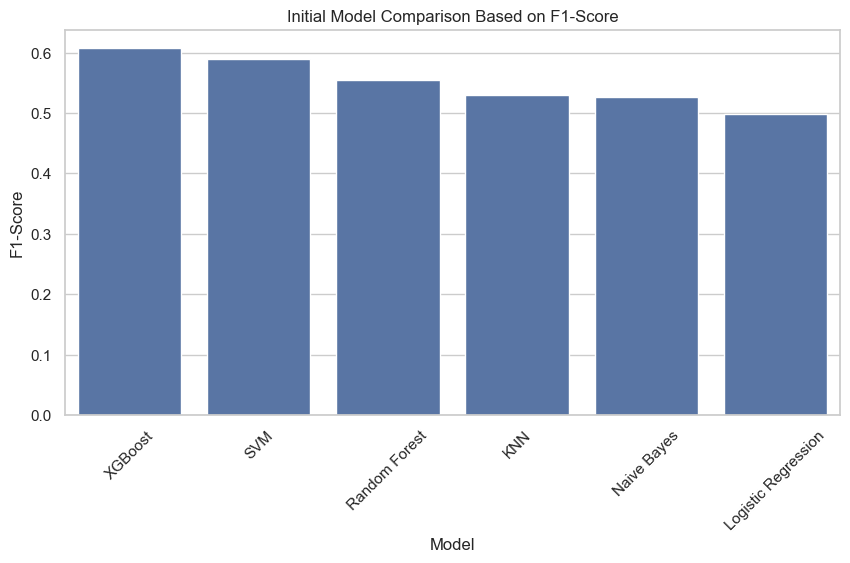

In [87]:
plt.figure(figsize=(10, 5))
sns.barplot(data=initial_results_sorted, x='Model', y='F1-Score')
plt.title('Initial Model Comparison Based on F1-Score')
plt.xlabel('Model')
plt.ylabel('F1-Score')
plt.xticks(rotation=45)
plt.show()

**Observation:** XGBoost leads pre-tuning (F1 ≈ `0.607`, Recall ≈ `0.764`), followed by SVM (F1 ≈ `0.589`, Recall ≈ `0.735`). Random Forest has the best accuracy (≈ `0.860`) but a lower F1 (≈ `0.556`) and recall than XGBoost/SVM.

## 12. Confusion Matrices — Initial Models

TN / TP / FP / FN for each model. False Negatives (missed churners) matter most here.

In [88]:
initial_predictions = {
    'Logistic Regression': y_pred_log_reg,
    'Naive Bayes': y_pred_nb,
    'KNN': y_pred_knn,
    'SVM': y_pred_svm,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb
}

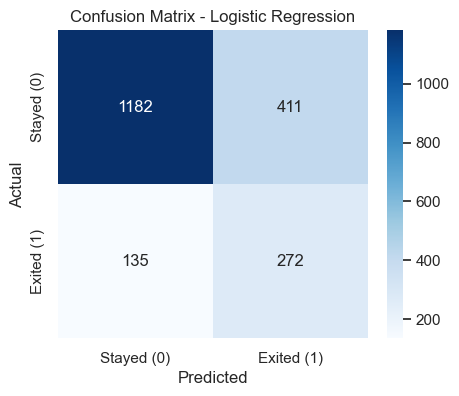

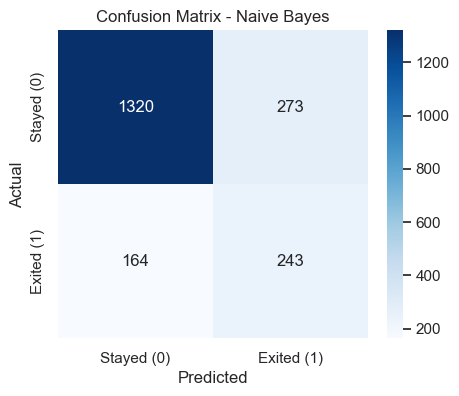

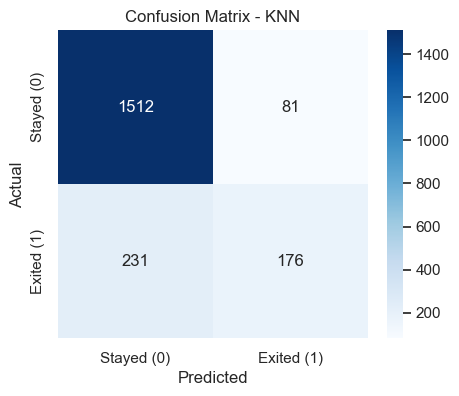

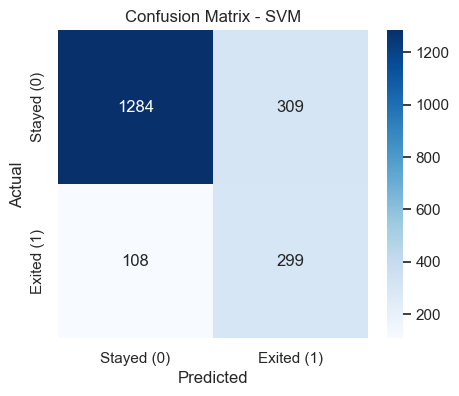

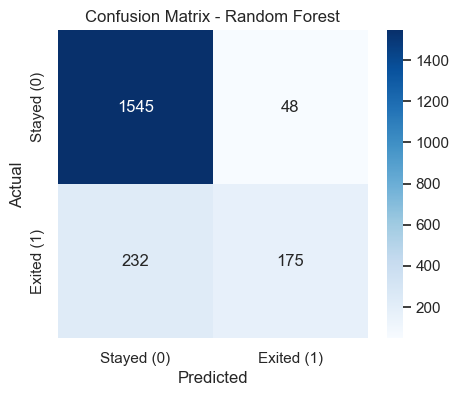

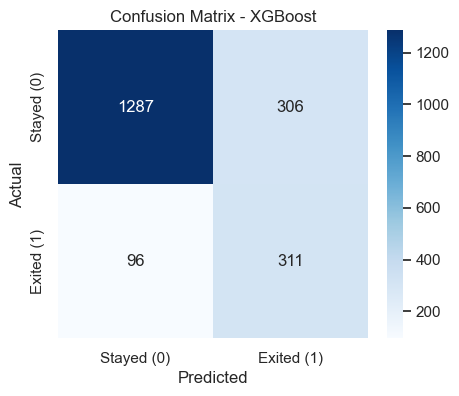

In [89]:
for model_name, y_pred in initial_predictions.items():
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Stayed (0)', 'Exited (1)'],
        yticklabels=['Stayed (0)', 'Exited (1)']
    )
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

## 13. Hyperparameter Tuning

Tuning KNN (`n_neighbors`, distance metric), Random Forest (tree count/depth/split params), and XGBoost (tree count, learning rate, depth) — scored on F1 due to the imbalance.

In [90]:
from sklearn.model_selection import GridSearchCV

### 13.1 Tuning KNN

Testing several `K` values and distance metrics; small K risks overfitting, large K risks underfitting.

In [91]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=knn_param_grid,
    scoring='f1',
    cv=3,
    n_jobs=1
)

knn_grid.fit(X_train_processed, y_train)

print("Best KNN Parameters:", knn_grid.best_params_)
print("Best KNN Cross-Validation F1-Score:", knn_grid.best_score_)

Best KNN Parameters: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
Best KNN Cross-Validation F1-Score: 0.5125984980250563


In [92]:
best_knn_model = knn_grid.best_estimator_
y_pred_knn_tuned = best_knn_model.predict(X_test_processed)
knn_tuned_result = evaluate_model('Tuned KNN', y_test, y_pred_knn_tuned)
knn_tuned_result

{'Model': 'Tuned KNN',
 'Accuracy': 0.8235,
 'Precision': 0.5882352941176471,
 'Recall': 0.44226044226044225,
 'F1-Score': 0.5049088359046283}

In [93]:
print(classification_report(y_test, y_pred_knn_tuned, target_names=['Stayed (0)', 'Exited (1)']))

              precision    recall  f1-score   support

  Stayed (0)       0.87      0.92      0.89      1593
  Exited (1)       0.59      0.44      0.50       407

    accuracy                           0.82      2000
   macro avg       0.73      0.68      0.70      2000
weighted avg       0.81      0.82      0.81      2000



### 13.2 Tuning Random Forest

Grid over `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`.

In [94]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=1
    ),
    param_grid=rf_param_grid,
    scoring='f1',
    cv=3,
    n_jobs=1
)

rf_grid.fit(X_train_processed, y_train)

print("Best Random Forest Parameters:", rf_grid.best_params_)
print("Best Random Forest Cross-Validation F1-Score:", rf_grid.best_score_)

Best Random Forest Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best Random Forest Cross-Validation F1-Score: 0.6198937188681706


In [95]:
best_rf_model = rf_grid.best_estimator_
y_pred_rf_tuned = best_rf_model.predict(X_test_processed)
rf_tuned_result = evaluate_model('Tuned Random Forest', y_test, y_pred_rf_tuned)
rf_tuned_result

{'Model': 'Tuned Random Forest',
 'Accuracy': 0.8385,
 'Precision': 0.5917030567685589,
 'Recall': 0.6658476658476659,
 'F1-Score': 0.6265895953757226}

In [96]:
print(classification_report(y_test, y_pred_rf_tuned, target_names=['Stayed (0)', 'Exited (1)']))

              precision    recall  f1-score   support

  Stayed (0)       0.91      0.88      0.90      1593
  Exited (1)       0.59      0.67      0.63       407

    accuracy                           0.84      2000
   macro avg       0.75      0.77      0.76      2000
weighted avg       0.85      0.84      0.84      2000



### 13.3 Tuning XGBoost

Grid over `n_estimators`, `max_depth`, `learning_rate` (lower learning rate ⇒ may need more trees).

In [97]:
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4],
    'learning_rate': [0.05, 0.1]
}
xgb_grid = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight
    ),
    param_grid=xgb_param_grid,
    scoring='f1',
    cv=3,
    n_jobs=1
)
xgb_grid.fit(X_train_processed, y_train)
print("Best XGBoost Parameters:", xgb_grid.best_params_)
print("Best XGBoost Cross-Validation F1-Score:", xgb_grid.best_score_)

Best XGBoost Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best XGBoost Cross-Validation F1-Score: 0.6127966548973685


In [98]:
best_xgb_model = xgb_grid.best_estimator_
y_pred_xgb_tuned = best_xgb_model.predict(X_test_processed)
xgb_tuned_result = evaluate_model('Tuned XGBoost', y_test, y_pred_xgb_tuned)
xgb_tuned_result

{'Model': 'Tuned XGBoost',
 'Accuracy': 0.799,
 'Precision': 0.5040518638573744,
 'Recall': 0.7641277641277642,
 'F1-Score': 0.607421875}

In [99]:
print(classification_report(y_test, y_pred_xgb_tuned, target_names=['Stayed (0)', 'Exited (1)']))

              precision    recall  f1-score   support

  Stayed (0)       0.93      0.81      0.86      1593
  Exited (1)       0.50      0.76      0.61       407

    accuracy                           0.80      2000
   macro avg       0.72      0.79      0.74      2000
weighted avg       0.84      0.80      0.81      2000



## 14. Final Model Comparison

Comparing all models post-tuning, focused on F1 and Recall.

In [100]:
final_results = pd.DataFrame([
    log_reg_result,
    nb_result,
    knn_result,
    svm_result,
    rf_result,
    xgb_result,
    knn_tuned_result,
    rf_tuned_result,
    xgb_tuned_result
])

final_results_sorted = final_results.sort_values(by='F1-Score', ascending=False)

final_results_sorted

,Model,Accuracy,Precision,Recall,F1-Score
7,Tuned Random Forest,0.8385,0.591703,0.665848,0.626590
8,Tuned XGBoost,0.7990,0.504052,0.764128,0.607422
5,XGBoost,0.7990,0.504052,0.764128,0.607422
3,SVM,0.7915,0.491776,0.734644,0.589163
4,Random Forest,0.8600,0.784753,0.429975,0.555556
2,KNN,0.8440,0.684825,0.432432,0.530120
1,Naive Bayes,0.7815,0.470930,0.597052,0.526544
6,Tuned KNN,0.8235,0.588235,0.442260,0.504909
0,Logistic Regression,0.7270,0.398243,0.668305,0.499083


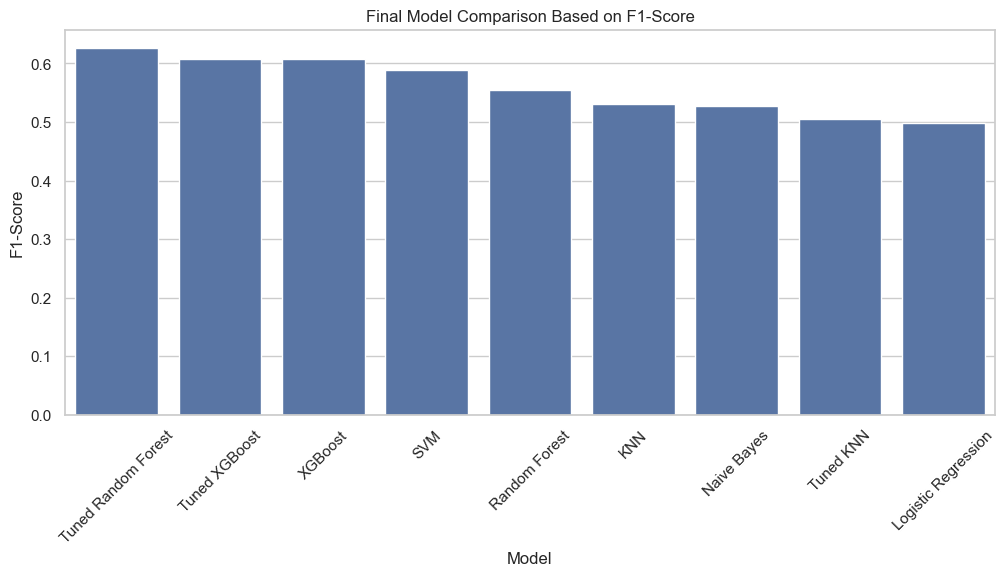

In [101]:
plt.figure(figsize=(12, 5))
sns.barplot(data=final_results_sorted, x='Model', y='F1-Score')
plt.title('Final Model Comparison Based on F1-Score')
plt.xlabel('Model')
plt.ylabel('F1-Score')
plt.xticks(rotation=45)
plt.show()

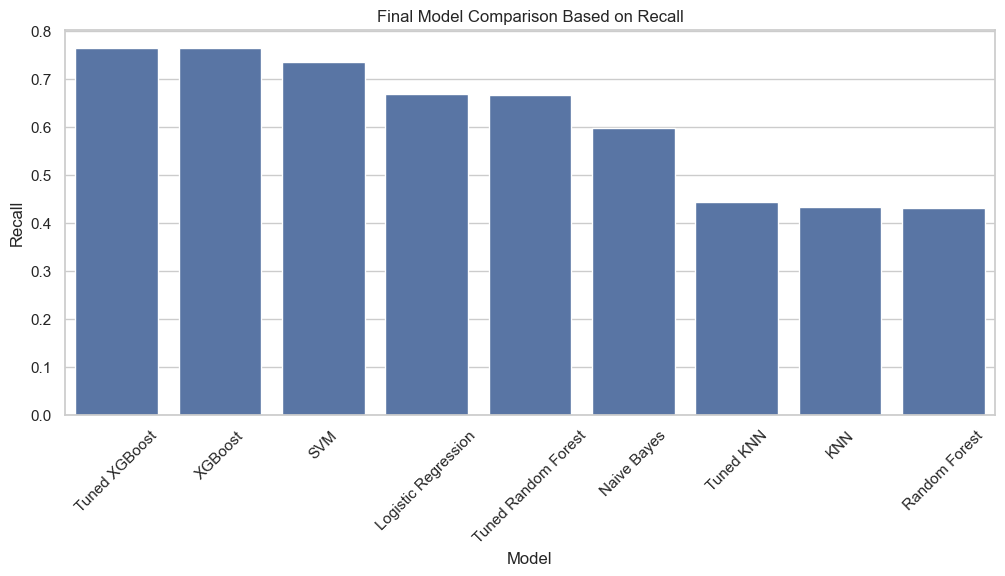

In [102]:
final_results_recall_sorted = final_results.sort_values(by='Recall', ascending=False)
plt.figure(figsize=(12, 5))
sns.barplot(data=final_results_recall_sorted, x='Model', y='Recall')
plt.title('Final Model Comparison Based on Recall')
plt.xlabel('Model')
plt.ylabel('Recall')
plt.xticks(rotation=45)
plt.show()

**Observation:** `Tuned Random Forest` wins on F1 (Accuracy ≈ `0.839`, Precision ≈ `0.592`, Recall ≈ `0.666`, F1 ≈ `0.627`). `XGBoost`/`Tuned XGBoost` trails slightly on F1 (≈ `0.607`) but has higher Recall (≈ `0.764`) with more false positives. **Trade-off:** Random Forest for the best overall balance, XGBoost if catching the most churners matters more.

## 15. Confusion Matrices — Tuned Models

Shows how tuning shifted False Positives vs. False Negatives.

In [103]:
tuned_predictions = {
    'Tuned KNN': y_pred_knn_tuned,
    'Tuned Random Forest': y_pred_rf_tuned,
    'Tuned XGBoost': y_pred_xgb_tuned
}

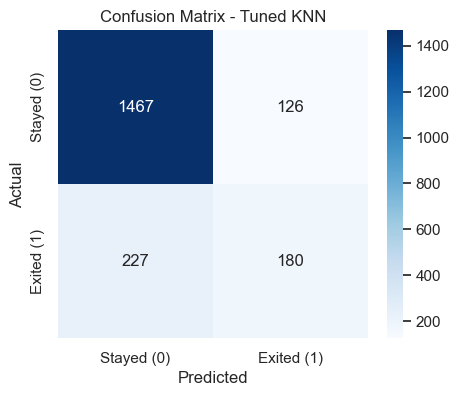

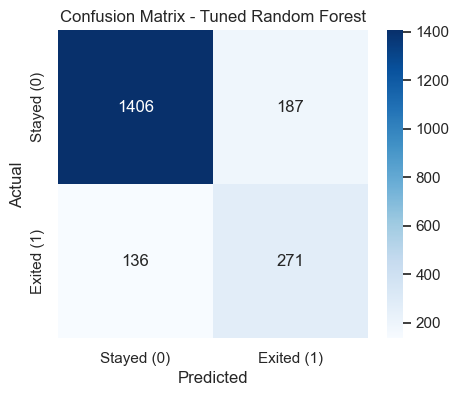

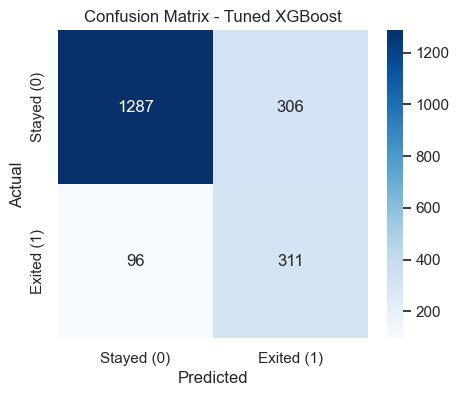

In [104]:
for model_name, y_pred in tuned_predictions.items():
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Stayed (0)', 'Exited (1)'],
        yticklabels=['Stayed (0)', 'Exited (1)']
    )
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

## 16. Final Report

Pipeline: load → clean → EDA → outliers → feature engineering → encode/scale → stratified split → baseline models → advanced models → hyperparameter tuning → comparison → confusion matrices.

In [105]:
best_model_row = final_results_sorted.iloc[0]
best_model_row

Model        Tuned Random Forest
Accuracy                  0.8385
Precision               0.591703
Recall                  0.665848
F1-Score                 0.62659
Name: 7, dtype: object

## Feature Importance Analysis

Feature importances from the final Tuned Random Forest, for interpretability.

In [106]:
encoded_cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = numerical_features + list(encoded_cat_features)
feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': best_rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance_df

,Feature,Importance
1,Age,0.231095
4,NumOfProducts,0.189692
13,AgeGroup_Middle_Aged,0.097475
3,Balance,0.080751
7,EstimatedSalary,0.065233
0,CreditScore,0.064983
9,BalanceSalaryRatio,0.061864
6,IsActiveMember,0.051185
10,Geography_Germany,0.047065
2,Tenure,0.038097


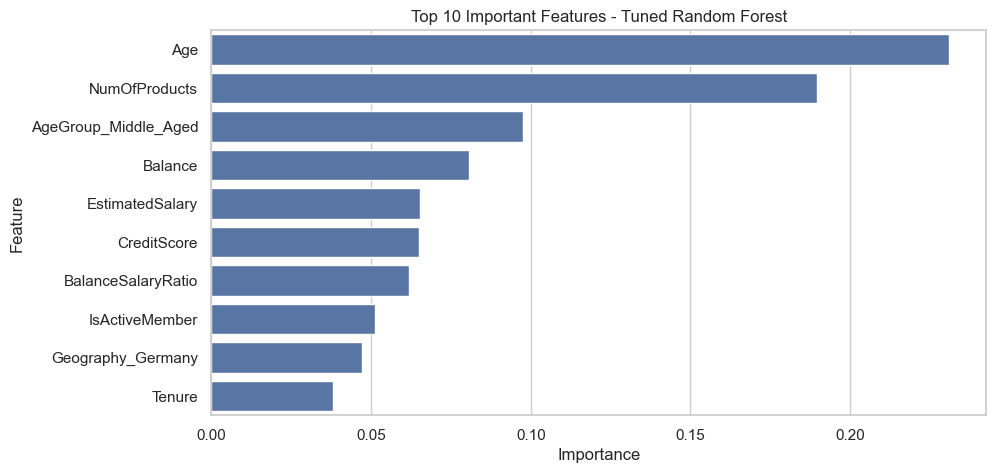

In [107]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=feature_importance_df.head(10),
    x='Importance',
    y='Feature'
)
plt.title('Top 10 Important Features - Tuned Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

**Observation:** shows the model is learning meaningful, explainable patterns rather than just fitting noise.

### Final Conclusion

**Best model: Tuned Random Forest** — Accuracy ≈ `0.839`, Precision ≈ `0.592`, Recall ≈ `0.666`, **F1 ≈ `0.627`** (best Precision/Recall balance; accuracy wasn't the deciding metric given the imbalance). XGBoost had a Recall edge but a lower F1, so Random Forest was selected as final.

### Where the Model May Fail

- **Class imbalance** makes churners harder to detect.
- **False Negatives** — missed churners the bank won't act on.
- **False Positives** — wasted retention effort on customers who weren't leaving.
- **Missing signals** the dataset lacks: complaints, transaction frequency, satisfaction scores, support calls, recent activity.
- **Recall vs. Precision trade-off** is ultimately a business decision, not just a modeling one.

## Final Notes

Implemented Logistic Regression, Naive Bayes, KNN, SVM, Random Forest, plus XGBoost as a bonus model — with full cleaning, EDA, outlier checks, feature engineering, encoding/scaling, stratified split, tuning, comparison, and confusion-matrix analysis.

**Final model: Tuned Random Forest** — best F1 and Precision/Recall balance.

## 17. Saving the Model for Deployment

Save both the fitted **preprocessor** and the trained **model** — the model expects already-preprocessed input, not raw values.

In [113]:
import joblib

best_rf_model = rf_grid.best_estimator_

deployment_package = {
    "preprocessor": preprocessor,
    "model": best_rf_model,
    "numerical_features": numerical_features,
    "categorical_features": categorical_features,
    "sklearn_version": __import__("sklearn").__version__
}

joblib.dump(deployment_package, "bank_churn_model.pkl", compress=3)

print("Saved successfully!")

Saved successfully!


In [109]:

loaded_package = joblib.load("bank_churn_model.pkl")

loaded_preprocessor = loaded_package["preprocessor"]
loaded_model = loaded_package["model"]

print("Model loaded successfully!")

Model loaded successfully!


In [110]:


sample_customer = pd.DataFrame({
    'CreditScore': [650],
    'Geography': ['France'],
    'Gender': ['Female'],
    'Age': [42],
    'Tenure': [5],
    'Balance': [100000],
    'NumOfProducts': [2],
    'HasCrCard': [1],
    'IsActiveMember': [0],
    'EstimatedSalary': [90000]
})

In [111]:

def create_age_group(age):
    if age < 30:
        return 'Young'
    elif age < 45:
        return 'Adult'
    elif age < 60:
        return 'Middle_Aged'
    else:
        return 'Senior'


sample_customer['AgeGroup'] = sample_customer['Age'].apply(create_age_group)
sample_customer['IsZeroBalance'] = (sample_customer['Balance'] == 0).astype(int)
sample_customer['BalanceSalaryRatio'] = np.log1p(
    sample_customer['Balance'] / (sample_customer['EstimatedSalary'] + 1)
)

sample_customer

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,AgeGroup,IsZeroBalance,BalanceSalaryRatio
0,650,France,Female,42,5,100000,2,1,0,90000,Adult,0,0.747209


In [112]:

sample_customer_processed = loaded_preprocessor.transform(sample_customer)

prediction = loaded_model.predict(sample_customer_processed)[0]

prediction_probability = loaded_model.predict_proba(sample_customer_processed)[0][1]

print("Prediction:", prediction)

if prediction == 1:
    print("Result: The customer is likely to leave the bank.")
else:
    print("Result: The customer is likely to stay with the bank.")

print("Churn Probability:", prediction_probability)

Prediction: 0
Result: The customer is likely to stay with the bank.
Churn Probability: 0.3669109769939211
